<div style="
border-left:6px solid #2a6fdb;
background-color:#f5f7fa;
padding:15px;
font-size:32px;
font-weight:600;
">
Métaheuristiques pour le problème du voyageur de commerce (TSP)
</div>

<p style="margin-top:10px;font-size:18px;text-align:right">
Réalisé par : <b>Amal Aabour</b>
</p>
<p style="margin-top:10px;font-size:18px;text-align:right">
Encadré par : <b>Dr. Mustapha OUDANI</b>
</p>

<div style="background-color:#f2f6fc; padding:15px; border-left:6px solid #1f77b4;">
<h1 style="margin:0;"> Partie 4 - Analyse des résultats expérimentaux</h1>
</div>

<div style="margin-left:20px;padding:10px;border-left:4px solid #6c8cd5;background:#f8f9fa;border-radius:6px">

<h3 style="margin-top:0">Lecture des données</code></h3>

<p>L’ensemble des résultats expérimentaux a été stocké dans un fichier CSV <b>results.csv</b>, permettant de centraliser les données et de faciliter leur analyse à l’aide de la bibliothèque pandas.</p>
</div>

In [52]:
import pandas as pd

df = pd.read_csv("results.csv")
display(df)

,categorie,instance,taille,optimal,solution,gap,temps
0,small,eil51,51,426,428.982,0.700,0.819
1,small,berlin52,52,7542,7544.366,0.031,0.512
2,small,st70,70,675,687.142,1.799,0.266
3,Medium,kroA100,100,21282,21624.702,1.610,0.464
4,Medium,ch150,150,6528,6650.839,1.882,0.265
5,Medium,d198,198,15780,16087.629,1.949,0.130
6,Large,lin318,318,42029,45318.083,7.826,0.641
7,Large,pr439,439,107217,116522.778,8.679,0.348
8,Large,pcb442,442,50778,54753.861,7.830,0.593
9,Large,rat575,575,6773,7332.763,8.265,2.103


<div style="margin-left:20px;padding:10px;border-left:4px solid #6c8cd5;background:#f8f9fa;border-radius:6px">

<h3 style="margin-top:0">Analyse globale des performances</code></h3>

</div>

In [19]:
from IPython.display import display, HTML


gap_moyen = df["gap"].mean()
temps_moyen = df["temps"].mean()

display(HTML(f"""
<h3 style="color:#2c3e50;">Analyse globale des performances</h3>

<table style="border-collapse:collapse;font-size:16px;">
<tr>
<td style="padding:6px 12px;"><b>Gap moyen :</b></td>
<td style="padding:6px 12px;color:#1f77b4;">{round(gap_moyen,3)}</td>
</tr>

<tr>
<td style="padding:6px 12px;"><b>Temps moyen :</b></td>
<td style="padding:6px 12px;color:#d62728;">{round(temps_moyen,3)}</td>
</tr>
</table>
"""))

Gap moyen :,4.057
Temps moyen :,0.614


Le gap moyen obtenu sur l’ensemble des instances est de **4.057%**, ce qui montre que l’algorithme produit des solutions relativement proches de l’optimum.

<div style="margin-left:20px;padding:10px;border-left:4px solid #6c8cd5;background:#f8f9fa;border-radius:6px">

<h3 style="margin-top:0">Analyse par catégorie (Small / Medium / Large)</code></h3>

</div>

In [21]:
df.groupby("categorie")[["gap","temps"]].mean()

,gap,temps
categorie,,
Large,8.150000,0.921250
Medium,1.813667,0.286333
small,0.843333,0.532333


Les résultats montrent que l’algorithme obtient des solutions très proches de l’optimal pour les petites instances, 
avec un gap moyen inférieur à 1%.
Pour les instances moyennes, le gap reste inférieur à 2%.
En revanche, pour les grandes instances, l’écart augmente en raison de l’augmentation de la taille de l’espace de recherche.

<div style="margin-left:20px;padding:10px;border-left:4px solid #6c8cd5;background:#f8f9fa;border-radius:6px">

<h3 style="margin-top:0">Meilleure et pire performance</code></h3>

</div>

In [28]:
from IPython.display import display, HTML
import pandas as pd
easy = df.loc[df["gap"].idxmin()]
hard = df.loc[df["gap"].idxmax()]
summary = pd.DataFrame({
    "Type": ["Instance la plus facile", "Instance la plus difficile"],
    "Instance": [easy["instance"], hard["instance"]],
    "Catégorie": [easy["categorie"], hard["categorie"]],
    "Taille": [easy["taille"], hard["taille"]],
    "Gap (%)": [round(easy["gap"],3), round(hard["gap"],3)]
})

display(HTML("<h3>Analyse de difficulté des instances</h3>"))
display(summary)

,Type,Instance,Catégorie,Taille,Gap (%)
0,Instance la plus facile,berlin52,small,52,0.031
1,Instance la plus difficile,pr439,Large,439,8.679


<div style="margin-left:20px;padding:10px;border-left:4px solid #6c8cd5;background:#f8f9fa;border-radius:6px">

<h3 style="margin-top:0">Impact de la taille sur les performances</code></h3>

</div>

In [23]:
df[["taille","gap","temps"]].sort_values("taille")

,taille,gap,temps
0,51,0.700,0.819
1,52,0.031,0.512
2,70,1.799,0.266
3,100,1.610,0.464
4,150,1.882,0.265
5,198,1.949,0.130
6,318,7.826,0.641
7,439,8.679,0.348
8,442,7.830,0.593
9,575,8.265,2.103


On observe que l’écart augmente généralement avec la taille de l’instance, ce qui est attendu puisque l’espace de recherche du problème du voyageur de commerce croît exponentiellement avec le nombre de villes.

<div style="margin-left:20px;padding:10px;border-left:4px solid #6c8cd5;background:#f8f9fa;border-radius:6px">

<h3 style="margin-top:0">Graphiques</code></h3>

</div>

### Gap vs taille

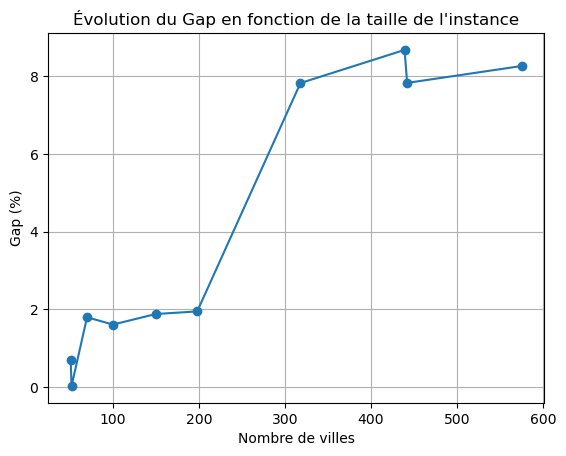

In [58]:

import matplotlib.pyplot as plt

# trier les données par taille
df_sorted = df.sort_values("taille")

plt.plot(df_sorted["taille"], df_sorted["gap"], marker='o')
plt.xlabel("Nombre de villes")
plt.ylabel("Gap (%)")
plt.title("Évolution du Gap en fonction de la taille de l'instance")

plt.grid(True)
plt.show()

Le graphique représentant l’évolution du gap en fonction de la taille des instances montre que l’écart entre la solution obtenue et la solution optimale reste très faible pour les petites et moyennes instances. En revanche, pour les grandes instances, le gap augmente de manière plus significative, ce qui est attendu compte tenu de la croissance de la complexité du problème. Malgré cela, l’algorithme conserve des performances relativement stables, avec un gap inférieur à 9 %, même pour les instances comportant plusieurs centaines de villes.

### Temps vs taille

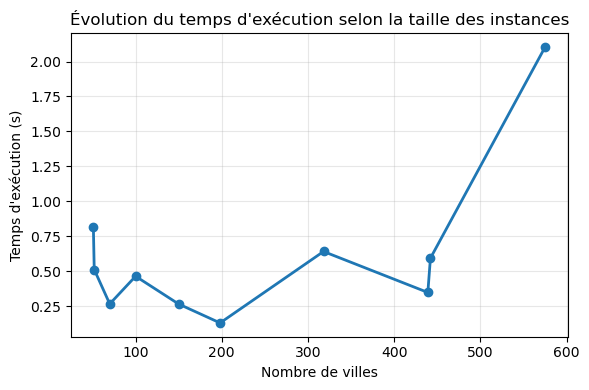

In [60]:
import matplotlib.pyplot as plt

# trier les données
df_sorted = df.sort_values("taille")

plt.figure(figsize=(6,4))

plt.plot(df_sorted["taille"], df_sorted["temps"], 
         marker='o', linewidth=2)

plt.xlabel("Nombre de villes")
plt.ylabel("Temps d'exécution (s)")
plt.title("Évolution du temps d'exécution selon la taille des instances")

plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

Le graphique représentant l'évolution du temps d'exécution en fonction de la taille des instances montre que le temps ne croît pas strictement de manière monotone avec le nombre de villes. Certaines instances de taille moyenne présentent un temps d'exécution comparable ou inférieur à celui d'instances plus petites. Ce comportement s'explique par la nature heuristique de l'algorithme utilisé ainsi que par la structure spatiale spécifique de chaque instance. En revanche, on observe une augmentation plus significative du temps pour les instances de très grande taille, ce qui est cohérent avec l'augmentation de la complexité du problème.

<div style="margin-left:20px;padding:10px;border-left:4px solid #6c8cd5;background:#f8f9fa;border-radius:6px">

<h3 style="margin-top:0">Tableau récapitulatif par catégorie</code></h3>

</div>

In [30]:
summary = df.groupby("categorie").agg({
    "gap":"mean",
    "temps":"mean"
})

summary

,gap,temps
categorie,,
Large,8.150000,0.921250
Medium,1.813667,0.286333
small,0.843333,0.532333


Les résultats expérimentaux montrent que l’algorithme proposé obtient des solutions très proches de l’optimal pour les petites et moyennes instances.
Pour les grandes instances, l’écart augmente légèrement en raison de la taille plus importante de l’espace de recherche.
Cependant, les temps d’exécution restent relativement faibles même pour les instances contenant plusieurs centaines de villes, ce qui démontre l’efficacité de la méthode proposée.